# Community detection algorithms

### Dependencies

- matplotlib
- networkx
- python-louvain
- community
- itertools

To install packages (for example networkx), run `pip install networkx` in the code cell or the terminal.

Consider Zachary’s Karate Club graph.

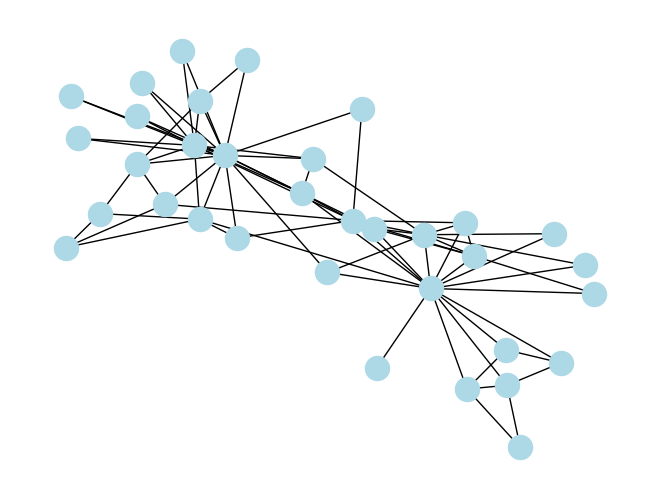

In [18]:
import networkx as nx

G = nx.karate_club_graph()
nx.draw_spring(G, node_color="lightblue")

### 1. Louvain algorithm: maximizes modularity

#### Obtaining the community structure having highest modularity.

Modularity of the best partition  = 0.4345214669889994


C:\Users\nidhi\AppData\Local\Temp\ipykernel_13144\830812450.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


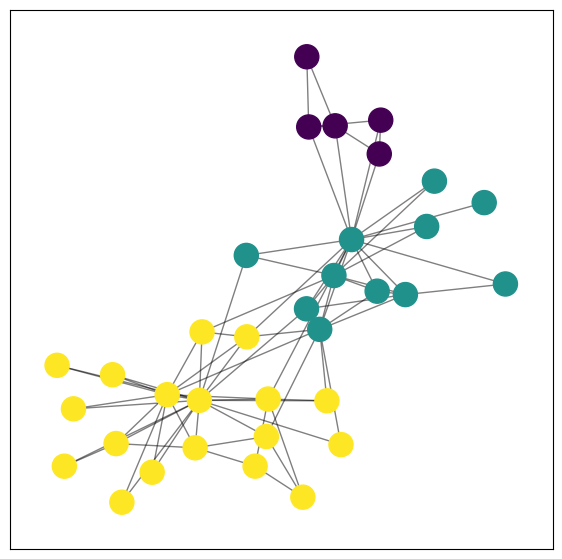

In [19]:
from community import community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# compute the best partition
partition = community_louvain.best_partition(G)
M = community_louvain.modularity(partition,G)
print(f'Modularity of the best partition  = {M}')
# draw the graph
pos = nx.spring_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=300,
                    cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

#### We can also obtain partitions at different levels by setting the resolution parameter.

Modularity of the partition  = 0.2500140552088604


C:\Users\nidhi\AppData\Local\Temp\ipykernel_13144\3401888435.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


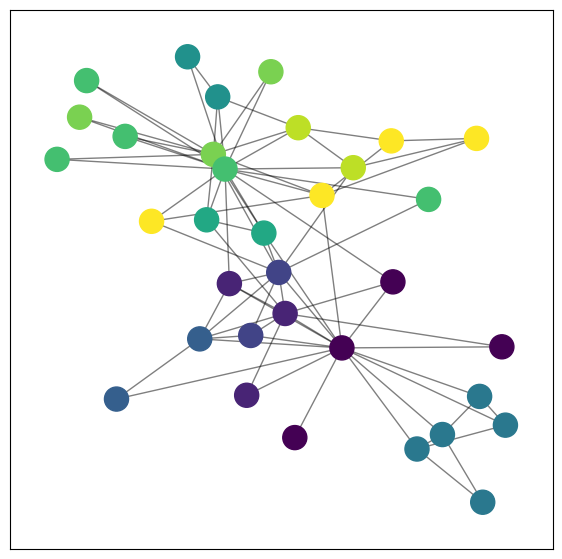

In [20]:
# set the resolution parameter, r = 1 (by default), r > 1 yields smaller communities and vice-versa
r = 3
# compute the partition at a certain resolution r
partition = community_louvain.best_partition(G, resolution=r)
M = community_louvain.modularity(partition,G)
print(f'Modularity of the partition  = {M}')

# draw the graph
pos = nx.spring_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=300,
                    cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

### 2. Girvan-Newman's method: deletes edges having maximum edge betweeness

In [21]:
import itertools

k = 3 # generates communities upto k levels

node_groups = []
comp = nx.community.girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))
    node_groups.append(list(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 16], [9])


#### We can visualize the community structure for different levels

C:\Users\nidhi\AppData\Local\Temp\ipykernel_13144\4094603045.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


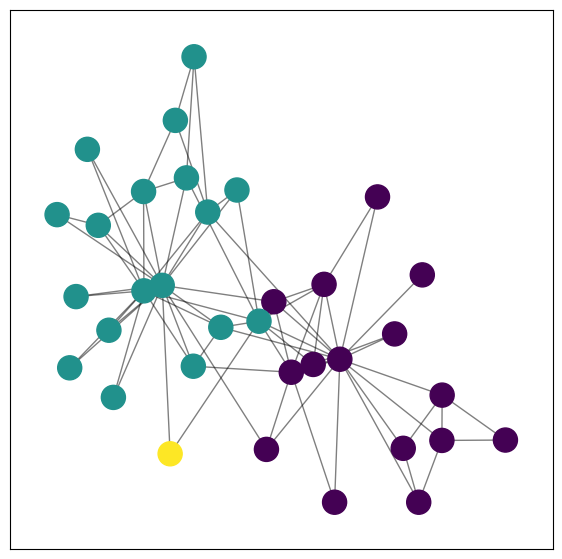

In [22]:
# set the level at which you want to visualize the community structure
level = 2

# Community affiliations
partition = {}
for node_group in node_groups[level-1]:
    for node in node_group:
        partition[node] = node_groups[level-1].index(node_group)
        
pos = nx.spring_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=300,
                    cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()